## Drafts

In [1]:
from dm_control import mjcf,mujoco
import PIL.Image

In [2]:
import copy
import os
import itertools
from IPython.display import clear_output
import numpy as np

%matplotlib inline

# Graphics-related
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython import display
import PIL.Image

from tempfile import NamedTemporaryFile
# Internal loading of video libraries.

# Use svg backend for figure rendering
%config InlineBackend.figure_format = 'svg'

# Font sizes
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


VIDEO_TAG = """<video controls>
 <source src="data:video/x-m4v;base64,{0}" type="video/mp4">
 Your browser does not support the video tag.
</video>"""

def anim_to_html(anim):
    if not hasattr(anim, '_encoded_video'):
        with NamedTemporaryFile(suffix='.mp4') as f:
            anim.save(f.name, fps=20, extra_args=['-vcodec', 'libx264'])
            video = open(f.name, "rb").read()
        anim._encoded_video = video.encode("base64")
    
    return VIDEO_TAG.format(anim._encoded_video)

# Inline video helper function
if os.environ.get('COLAB_NOTEBOOK_TEST', False):
  # We skip video generation during tests, as it is quite expensive.
  display_video = lambda *args, **kwargs: None
else:
  def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    video=anim.to_html5_video()

    html = display.HTML(video) 
  
    # draw the animation 
    display.display(html)

# Seed numpy's global RNG so that cell outputs are deterministic. We also try to
# use RandomState instances that are local to a single cell wherever possible.
np.random.seed(42)

In [3]:
root_dir = os.getcwd()
print(root_dir)

/home/vignesh/robot-collab_vig


In [4]:
sort_task=mjcf.RootElement(model='sort_task')
sort_task.compiler.angle="radian"
sort_task.compiler.autolimits="true"

sort_task.visual.headlight.diffuse="0.6 0.6 0.6"
sort_task.visual.headlight.ambient="0.1 0.1 0.1"
sort_task.visual.headlight.specular="0 0 0"
sort_task.visual.__getattr__('global').azimuth="0"
sort_task.visual.__getattr__('global').elevation="-30"
sort_task.visual.__getattr__('global').offwidth="1000"
sort_task.visual.__getattr__('global').offheight="1000"
sort_task.visual.quality.shadowsize="4096"

# /home/adityadutt/Desktop/robot-collab-v2/rocobench/envs
light_wood_texture=sort_task.asset.add('texture',file= root_dir + '/rocobench/envs/assets/objects/textures/light-wood.png',type="2d",name='tex-light-wood')
light_wood=sort_task.asset.add('material',name='light-wood',reflectance=0.2,texrepeat="15 15",texture='tex-light-wood',texuniform='true')
chequered = sort_task.asset.add('texture', type='2d', builtin='checker', width=300, height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
groundplane = sort_task.asset.add('material', name='grid', texture=chequered, texrepeat=[2, 2], reflectance=.2)

In [5]:
sort_task.worldbody.add('light',pos="0 0 1.5",dir="0 0 -1",directional="true")
sort_task.worldbody.add('geom',name="floor",pos="0 0 -0.5",size="0 0 0.05", type="plane",material=groundplane)
#panda=mjcf.from_path('/home/vignesh/robot-collab_vig/rocobench/envs/assets/panda/panda.xml')
#sort_task.worldbody.attach(panda)
table_body=sort_task.worldbody.add('body',name='table',pos='0 0.5 0')
table_body.add('geom',name='table_collision',pos='0 0 0.1',size='1.6 0.4 0.05', type='box', group='0', friction='1 0.5 0.0001',rgba='1 1 1 1')

table_top_body=table_body.add('body',name='table_top',pos='0 0 0.1')
table_top_body.add('geom',name='table_top',size='1.6 0.4 0.05',type='box',conaffinity='0',contype='0', group='1',rgba='1 1 1 1')

robot1_site=sort_task.worldbody.add('site',name='robot1',pos='-0.5 -0.05 0.1')
robot2_site=sort_task.worldbody.add('site',name='robot2',pos='0.5 1.05 0.1',euler='0 0 3.14159')
robot3_site=sort_task.worldbody.add('site',name='robot3',pos='-0.5 1.05 0.1')#,euler='0 0 3.14159')
robot1=mjcf.from_path(root_dir + '/rocobench/envs/assets/panda/panda.xml')
robot1.model='panda1'
#robot2=mjcf.from_path('/home/vignesh/robot-collab_vig/rocobench/envs/assets/panda/panda.xml')
#robot2.model='ur5e'

robot3=mjcf.from_path(root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml')
robot3.model='ur5e'

robot1_site.attach(robot1)
#robot2_site.attach(robot2)
robot3_site.attach(robot3)
table_body.add('geom',name='table_left',pos='-1.63 0 1', size='0.02 1.6 1.5', rgba='1 1 1 0', type='box')
table_body.add('geom',name='table_right',pos='1.63 0 1', size='0.02 1.6 1.5', rgba='1 1 1 0', type='box')
table_body.add('geom',name='table_front',pos='0 1.63 1', size='1.7 0.02 1.5', rgba='1 1 1 0', type='box')
table_body.add('geom',name='table_back',pos='0 -1.63 1', size='1.7 0.02 1.5', rgba='1 1 1 0', type='box')

sort_task.worldbody.add('camera', mode="fixed", name='face_panda1', pos="0.062 -2.806 0.768", xyaxes="1.000 0.009 -0.000 0.001 -0.131 0.991")
sort_task.worldbody.add('camera', mode="fixed", name='face_panda2', pos="0.084 3.711 0.772", xyaxes="-1.000 0.016 0.000 0.002 0.111 0.994")
sort_task.worldbody.add('camera', mode="fixed", name='top_cam', pos="-0.001 0.652 2.057", xyaxes="-1.000 -0.000 -0.000 0.000 -1.000 0.019")
sort_task.worldbody.add('camera', mode="fixed", name='right_cam', pos="1.873 0.605 0.926", xyaxes="0.014 1.000 0.000 -0.242 0.003 0.970")
sort_task.worldbody.add('camera', mode="fixed", name='left_cam', pos="-1.873 0.605 0.926", xyaxes="-0.000 -1.000 0.000 0.177 -0.000 0.984")
sort_task.worldbody.add('camera', name='teaser', pos="2.675 -0.747 1.997", xyaxes="0.496 0.869 -0.000 -0.429 0.245 0.869")
sort_task.worldbody.add('camera', name='video', pos="1.957 -0.281 1.731", xyaxes="0.487 0.874 0.000 -0.500 0.278 0.820")

MJCF Element: <camera name="video" class="/" pos="1.9570000000000001 -0.28100000000000003 1.7310000000000001" xyaxes="0.48699999999999999 0.874 0 -0.5 0.27800000000000002 0.81999999999999995"/>

In [6]:
bin_body1=table_top_body.add('body',name='bin1',pos='-0.5 0 0.05')
bin_body1.add('geom',name='bottom1',type='box',size='0.35 0.2 0.02',friction="1 0.005 0.0001",material='light-wood')
bin_body1.add('geom',name='front1',type='box',pos='0 0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body1.add('geom',name='back1',type='box',pos='0 -0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body1.add('geom',name='right1',type='box',pos='0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body1.add('geom',name='left1',type='box',pos='-0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')

box=sort_task.worldbody.add('body',name='black_box',pos='-0.5 0.5 0.1')
box.add('joint',type='free',name='box_free')
box.add('body',name='box_top',pos='0 0 0.03')
box.add('body',name='box_bottom',pos='0 0 -0.03')
box.add('site',name='box_top',type='sphere',pos='0 0 0.03')
box.add('site',name='box_bottom',type='sphere',pos='0 0 -0.03')
box.add('geom',name='box_collision',type='box',size='0.03 0.03 0.03',rgba='0 0 0 1')

bin_body2=table_top_body.add('body',name='bin2',pos='0.5 0 0.05')
bin_body2.add('geom',name='bottom2',type='box',size='0.35 0.2 0.02',friction="1 0.005 0.0001",material='light-wood')
bin_body2.add('geom',name='front2',type='box',pos='0 0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body2.add('geom',name='back2',type='box',pos='0 -0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body2.add('geom',name='right2',type='box',pos='0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body2.add('geom',name='left2',type='box',pos='-0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')
bin_body=sort_task.worldbody.add('body', name="bin", pos="0.45 0.5 0.16")
bin_inside_body=bin_body.add('body', name="bin_inside", pos="0 0 0")
bin_inside_body.add('geom', name="bin_inside_bottom", pos="0 0 0", size="0.35 0.2 0.02", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
bin_inside_body.add('geom', name="bin_inside_front", pos="0 0.2 0.03", size="0.35 0.01 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
bin_inside_body.add('geom', name="bin_inside_back", pos="0 -0.2 0.03", size="0.35 0.01 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
bin_inside_body.add('geom', name="bin_inside_right", pos="0.38 0 0.03", size="0.01 0.18 0.06", type="box", group="3", friction="1 0.005 0.0001", rgba="1 0 0 0")
bin_inside_body.add('geom', name="bin_inside_left", pos="-0.38 0 0.03", size="0.01 0.18 0.06", type="box", group="3", friction="1 0.005 0.0001", rgba="1 0 0 0" )

bin_body.add('geom', name="bin_right", pos="0.35 0 0.03", size="0.01 0.2 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood", margin="0.01")
bin_body.add('geom', name="bin_left", pos="-0.35 0 0.03", size="0.01 0.2 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood", margin="0.01")

MJCF Element: <geom name="bin_left" class="/" type="box" group="3" size="0.01 0.20000000000000001 0.059999999999999998" material="light-wood" friction="1 0.0050000000000000001 0.0001" margin="0.01" pos="-0.34999999999999998 0 0.029999999999999999"/>

In [7]:
#sort_task.contact.add('pair', name="milk_panda", geom1="panda1/panda_hand_collision", geom2="box_collision", margin="0.05")
# sort_task.equality.add('weld',name='panda1_top',body1='box_top',body2='panda1/panda_palm',relpose='0 0 0 1 0 0 0',active='false')
# sort_task.equality.add('weld',name='panda1_bottom',body1='box_bottom',body2='panda1/panda_palm',relpose='0 0 0 1 0 0 0',active='false')

# sort_task.equality.add('weld',name='ur5e_top',body1='box_top',body2='ur5e/robotiq_tip',relpose='0 0 0 1 0 0 0',active='false')
# sort_task.equality.add('weld',name='ur5e_bottom',body1='box_bottom',body2='ur5e/robotiq_tip',relpose='0 0 0 1 0 0 0',active='false')
#sort_task.equality.add('weld',name='ur5e_top',body1='box_top',body2='ur5e/panda_palm',relpose='0 0 0 1 0 0 0',active='false')
#sort_task.equality.add('weld',name='ur5e_bottom',body1='box_bottom',body2='ur5e/panda_palm',relpose='0 0 0 1 0 0 0',active='false')
panda_qpos0='0 0 0 0 -1.57079 0 1.57079 -0.7853 0.04 0.04'
ur5_qpos0='0 -1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0 0 0 0 0 0 0 0'
box_qpos0='-0.5 0.5 0.22 0 0 0 0'
panda_ctrl0='0 0 0 0 -1.57079 0 1.57079 -0.7853 255'
ur5_ctrl0='0 1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0'
sort_task.keyframe.add('key',name='home',qpos=panda_qpos0+' '+ur5_qpos0+' '+box_qpos0, ctrl=panda_ctrl0+' '+ur5_ctrl0)

MJCF Element: <key name="home" qpos="0 0 0 0 -1.5707899999999999 0 1.5707899999999999 -0.7853 0.040000000000000001 0.040000000000000001 0 -1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0 0 0 0 0 0 0 0 -0.5 0.5 0.22 0 0 0 0" ctrl="0 0 0 0 -1.5707899999999999 0 1.5707899999999999 -0.7853 255 0 1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0"/>

In [8]:
print(sort_task.to_xml_string())
# f = open("task_handover.xml", "w")
# f.write(sort_task.to_xml_string())
# f.close()


<mujoco model="sort_task">
  <compiler autolimits="true" angle="radian"/>
  <option integrator="implicit"/>
  <visual>
    <global azimuth="0" elevation="-30" offwidth="1000" offheight="1000"/>
    <quality shadowsize="4096"/>
    <headlight ambient="0.10000000000000001 0.10000000000000001 0.10000000000000001" diffuse="0.59999999999999998 0.59999999999999998 0.59999999999999998" specular="0 0 0"/>
  </visual>
  <default>
    <default class="/"/>
    <default class="panda1/">
      <default class="panda1/panda">
        <material specular="0.5" shininess="0.25"/>
        <joint axis="0 0 1" range="-2.8973 2.8973" armature="0.10000000000000001" damping="15"/>
        <general ctrlrange="-2.8973 2.8973" forcerange="-87 87" dyntype="none" biastype="affine"/>
        <default class="panda1/finger">
          <joint type="slide" axis="0 1 0" range="0 0.040000000000000001"/>
        </default>
        <default class="panda1/visual">
          <geom type="mesh" contype="0" conaffinity="0" grou

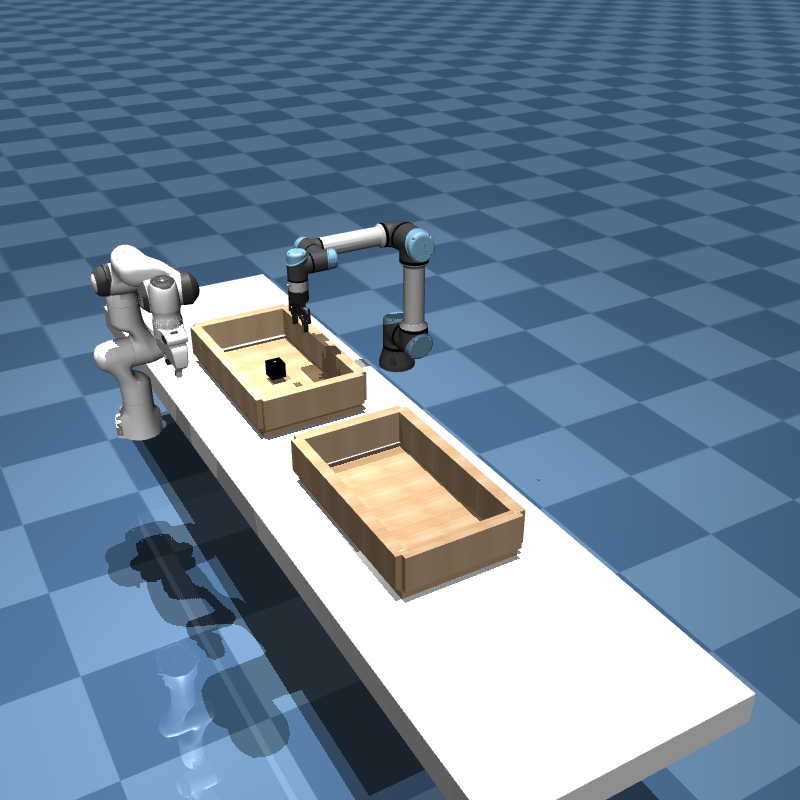

In [9]:
physics=mjcf.Physics.from_mjcf_model(sort_task)
physics.reset(0)
#final_physics=mjcf.from_path('/home/vignesh/robot-collab_vig/rocobench/envs/assets/ur5e/ur5e_robotiq_full.xml')
pixels=physics.render(width=800,height=800,camera_id=5)

ctrl_shape=physics.data.ctrl.shape
PIL.Image.fromarray(pixels)
#print(physics.named.data.qpos)
#print(physics.data.qvel.shape)



In [10]:
physics.named.data.xpos

FieldIndexer(xpos):
                                 x         y         z         
 0                       world [ 0         0         0       ]
 1                       table [ 0         0.5       0       ]
 2                   table_top [ 0         0.5       0.1     ]
 3                        bin1 [-0.5       0.5       0.15    ]
 4                        bin2 [ 0.5       0.5       0.15    ]
 5                     panda1/ [-0.5      -0.05      0.1     ]
 6                panda1/link0 [-0.5      -0.05      0.1     ]
 7                panda1/link1 [-0.5      -0.05      0.433   ]
 8                panda1/link2 [-0.5      -0.05      0.433   ]
 9                panda1/link3 [-0.5      -0.05      0.749   ]
10                panda1/link4 [-0.417    -0.05      0.749   ]
11                panda1/link5 [-0.0335   -0.05      0.832   ]
12                panda1/link6 [-0.0335   -0.05      0.832   ]
13                panda1/link7 [ 0.0545   -0.05      0.832   ]
14                 panda1/hand [ 0

In [11]:
sort_task.equality.add('weld',name='panda1_top',body1='box_top',body2='panda1/panda_palm',relpose='0 0 0 1 0 0 0',active='false')
sort_task.equality.add('weld',name='panda1_bottom',body1='box_bottom',body2='panda1/panda_palm',relpose='0 0 0 1 0 0 0',active='false')

sort_task.equality.add('weld',name='ur5e_top',body1='box_top',body2='ur5e/robotiq_tip',relpose='0 0 0 1 0 0 0',active='false')
sort_task.equality.add('weld',name='ur5e_bottom',body1='box_bottom',body2='ur5e/robotiq_tip',relpose='0 0 0 1 0 0 0',active='false')

MJCF Element: <weld name="ur5e_bottom" class="/" active="false" body1="box_bottom" body2="ur5e/robotiq_tip" relpose="0 0 0 1 0 0 0"/>

In [12]:
%reload_ext autoreload
%autoreload 2
from typing import Any, Dict
from rocobench.envs.base_mjcf_task import BaseTask
from rocobench.envs.constants import *
from copy import deepcopy


class ObjectHandover(BaseTask):
    def __init__(
            self, 
            model_name : str = "task", 
            project_root_dir : str = "", 
            filepath : str = None, 
            robots = None, 
            reset_to_home_pose = False, 
            create_weld=False
    ):
        
        super().__init__(model_name, project_root_dir, filepath) 
        
        #Set default classes
        self.set_dclasses()

        #Build the scene
        self.build_scene()
        
        # self.set_physics()
        # self.physics = mjcf.Physics.from_mjcf_model(self.model)
        # print("Physics before:", len(self.physics.data.qpos))

        #Store Robot Configs
        # self.robot_configs = {"panda": PANDA_CONSTANTS.copy(), "ur5e": UR5E_ROBOTIQ_CONSTANTS.copy(), 
        #                       "kinova": KINOVA_CONSTANTS.copy()}
    
        # #Add Robots
        self.add_robots(robot_dict=robots, create_weld=create_weld)
        print("Add Robots Works!")
        # self.set_physics()

        # print("Physics after:", len(self.physics.data.qpos))

        self.home_pose()

        # #If add cameras:
        self.add_cameras()

        self.set_physics()



        # self.create_SimRobots(robots= robots)

        # print("Sim Robot Works!")

        # ## Compute Door Pose for Open-Door
        # self.door_name = "cabinet/right_door_handle"
        # # doorcabinet.physics.named.data.xpos["cabinet/cabinet"] += [0., 0., 0.51]
        # self.cabinet_pos = self.physics.data.body("cabinet/cabinet").xpos.copy()
        # self.open_door_pose = self.compute_door_open_pose(self.door_name) #[3, 4]

        # ## Reset to home pose for now
        # if reset_to_home_pose:
        #     self.reset_to_home_pose()

    def build_scene(self,):
        self.light_wood_texture=self.model.asset.add('texture',file= self.project_root_dir + 'assets/objects/textures/light-wood.png',type="2d",name='tex-light-wood')
        self.light_wood=self.model.asset.add('material',name='light-wood',reflectance=0.2,texrepeat="15 15",texture='tex-light-wood',texuniform='true')
        checker = self.model.asset.add('texture', type='2d', builtin='checker', width=300, height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
        groundplane = self.model.asset.add('material', name='grid', texture=checker, texrepeat=[2, 2], reflectance=.2)

        self.model.worldbody.add('light',pos="0 0 1.5",dir="0 0 -1",directional="true")
        self.model.worldbody.add('geom',name="floor",pos="0 0 -0.5",size="0 0 0.05", type="plane",material=groundplane)
        self.table_body=self.model.worldbody.add('body',name='table',pos='0 0.5 0')
        self.table_body.add('geom',name='table_collision',pos='0 0 0.1',size='1.6 0.4 0.05', type='box', group='0', friction='1 0.5 0.0001',rgba='1 1 1 1')

        self.table_top_body = self.table_body.add('body',name='table_top',pos='0 0 0.1')
        self.table_top_body.add('geom',name='table_top',size='1.6 0.4 0.05',type='box',conaffinity='0',contype='0', group='1',rgba='1 1 1 1')

        self.table_body.add('geom',name='table_left',pos='-1.63 0 1', size='0.02 1.6 1.5', rgba='1 1 1 0', type='box')
        self.table_body.add('geom',name='table_right',pos='1.63 0 1', size='0.02 1.6 1.5', rgba='1 1 1 0', type='box')
        self.table_body.add('geom',name='table_front',pos='0 1.63 1', size='1.7 0.02 1.5', rgba='1 1 1 0', type='box')
        self.table_body.add('geom',name='table_back',pos='0 -1.63 1', size='1.7 0.02 1.5', rgba='1 1 1 0', type='box')

        self.bin_body1 = self.table_top_body.add('body',name='bin1',pos='-0.5 0 0.05')
        self.bin_body1.add('geom',name='bottom1',type='box',size='0.35 0.2 0.02',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body1.add('geom',name='front1',type='box',pos='0 0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body1.add('geom',name='back1',type='box',pos='0 -0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body1.add('geom',name='right1',type='box',pos='0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body1.add('geom',name='left1',type='box',pos='-0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')

        self.box = self.model.worldbody.add('body',name='black_box',pos='-0.5 0.5 0.1')
        self.box.add('freejoint', name='box_free')
        self.box.add('body',name='box_top',pos='0 0 0.03')
        self.box.add('body',name='box_bottom',pos='0 0 -0.03')
        self.box.add('site',name='box_top',type='sphere',pos='0 0 0.03')
        self.box.add('site',name='box_bottom',type='sphere',pos='0 0 -0.03')
        self.box.add('geom',name='box_collision',type='box',size='0.03 0.03 0.03',rgba='0 0 0 1')

        self.bin_body2 = self.table_top_body.add('body',name='bin2',pos='0.5 0 0.05')
        self.bin_body2.add('geom',name='bottom2',type='box',size='0.35 0.2 0.02',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body2.add('geom',name='front2',type='box',pos='0 0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body2.add('geom',name='back2',type='box',pos='0 -0.2 0.1',size='0.35 0.02 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body2.add('geom',name='right2',type='box',pos='0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')
        self.bin_body2.add('geom',name='left2',type='box',pos='-0.35 0 0.1',size='0.02 0.2 0.06',friction="1 0.005 0.0001",material='light-wood')

        self.bin_body = self.model.worldbody.add('body', name="bin", pos="0.45 0.5 0.16")
        self.bin_inside_body = self.bin_body.add('body', name="bin_inside", pos="0 0 0")
        self.bin_inside_body.add('geom', name="bin_inside_bottom", pos="0 0 0", size="0.35 0.2 0.02", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
        self.bin_inside_body.add('geom', name="bin_inside_front", pos="0 0.2 0.03", size="0.35 0.01 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
        self.bin_inside_body.add('geom', name="bin_inside_back", pos="0 -0.2 0.03", size="0.35 0.01 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood")
        self.bin_inside_body.add('geom', name="bin_inside_right", pos="0.38 0 0.03", size="0.01 0.18 0.06", type="box", group="3", friction="1 0.005 0.0001", rgba="1 0 0 0")
        self.bin_inside_body.add('geom', name="bin_inside_left", pos="-0.38 0 0.03", size="0.01 0.18 0.06", type="box", group="3", friction="1 0.005 0.0001", rgba="1 0 0 0" )

        self.bin_body.add('geom', name="bin_right", pos="0.35 0 0.03", size="0.01 0.2 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood", margin="0.01")
        self.bin_body.add('geom', name="bin_left", pos="-0.35 0 0.03", size="0.01 0.2 0.06", type="box", group="3", friction="1 0.005 0.0001", material="light-wood", margin="0.01")


    def home_pose(self,):
        panda_qpos0='0 0 0 0 -1.57079 0 1.57079 -0.7853 0.04 0.04'
        ur5_qpos0='0 -1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0 0 0 0 0 0 0 0'
        box_qpos0='-0.5 0.5 0.22 0 0 0 0'
        panda_ctrl0='0 0 0 0 -1.57079 0 1.57079 -0.7853 255'
        ur5_ctrl0='0 1.5708 -1.5708 1.5708 -1.5708 -1.5708 0 0'
        self.model.keyframe.add('key',name='home',
                                qpos=box_qpos0 + ' ' + panda_qpos0 + ' ' + ur5_qpos0, 
                                ctrl=panda_ctrl0+' '+ur5_ctrl0)

    def add_cameras(self):
        self.model.worldbody.add('camera', mode="fixed", name='face_panda1', pos="0.062 -2.806 0.768", xyaxes="1.000 0.009 -0.000 0.001 -0.131 0.991")
        self.model.worldbody.add('camera', mode="fixed", name='face_panda2', pos="0.084 3.711 0.772", xyaxes="-1.000 0.016 0.000 0.002 0.111 0.994")
        self.model.worldbody.add('camera', mode="fixed", name='top_cam', pos="-0.001 0.652 2.057", xyaxes="-1.000 -0.000 -0.000 0.000 -1.000 0.019")
        self.model.worldbody.add('camera', mode="fixed", name='right_cam', pos="1.873 0.605 0.926", xyaxes="0.014 1.000 0.000 -0.242 0.003 0.970")
        self.model.worldbody.add('camera', mode="fixed", name='left_cam', pos="-1.873 0.605 0.926", xyaxes="-0.000 -1.000 0.000 0.177 -0.000 0.984")
        self.model.worldbody.add('camera', name='teaser', pos="2.675 -0.747 1.997", xyaxes="0.496 0.869 -0.000 -0.429 0.245 0.869")
        self.model.worldbody.add('camera', name='video', pos="1.957 -0.281 1.731", xyaxes="0.487 0.874 0.000 -0.500 0.278 0.820")

    def render_image(
            self, 
            cam_id : int = 0, 
            qpos = None, 
            qpos_id = None, 
            width=1080, 
            height=800
    ):
        if qpos is None:
            # self.physics.reset()
            img = PIL.Image.fromarray(self.physics.render(camera_id=cam_id, width = width, height = height))
        else:
            with self.physics.reset_context():
                self.physics.data.qpos[qpos_id] = qpos
                self.physics.step()

                img = PIL.Image.fromarray(self.physics.render(camera_id=cam_id, width = width, height = height))
        return img
    
    def reset_to_home_pose(self,):
        self.physics.reset(0)

    """
    Gets the pose of the specified robot
    """
    def get_robot_pose(self, robot_name):
        return np.concatenate((self.physics.named.data.xpos[robot_name],self.physics.named.data.xquat[robot_name]),axis=0)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [13]:
def prepend_robot_name(name:str,constants: dict):
        result = dict()
        result["name"] = name
        for key, value in constants.items():
            #print(key)
            if key=='name':
                continue

            if key == "actuator_info":
                result[key] = {name + "/" + x: name + "/" + y for x, y in value.items()}
            elif key == "mesh_to_geoms":
                result[key] = {x: [name + "/" + y for y in z] for x, z in value.items()}

            elif isinstance(constants[key],str):
                result[key]= name+'/'+value
            else:
                result[key] = [name + "/" + x for x in value]

        return result

In [14]:
root_dir = os.getcwd()
robots = { 
            "panda": {
                "robot_config": prepend_robot_name("panda", PANDA_CONSTANTS.copy()),
                "robot_type": "panda",
                "file": root_dir + '/rocobench/envs/assets/panda/panda.xml',
                "worldbody_site_pos": [-0.5, -0.05,0.1]
            
            },
            "ur5e":{
                "robot_config": prepend_robot_name("ur5e", UR5E_ROBOTIQ_CONSTANTS.copy()),
                "robot_type": "ur5e",
                "file": root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml',
                "worldbody_site_pos": [-0.5, 1.05, 0.1]
            }
        }


t = ObjectHandover(project_root_dir=root_dir + '/rocobench/envs/', robots=robots)

Add Robots Works!


In [15]:
# t.physics.named.data.xpos["world"]
# t.model.get_assets()

In [16]:
t.physics.named.data.qpos, t.physics.named.data.ctrl

(FieldIndexer(qpos):
  0                        box_free [-0.5     ]
  1                        box_free [ 0.5     ]
  2                        box_free [ 0.1     ]
  3                        box_free [ 1       ]
  4                        box_free [ 0       ]
  5                        box_free [ 0       ]
  6                        box_free [ 0       ]
  7          panda/panda_base_joint [ 0       ]
  8                    panda/joint1 [ 0       ]
  9                    panda/joint2 [ 0       ]
 10                    panda/joint3 [ 0       ]
 11                    panda/joint4 [ 0       ]
 12                    panda/joint5 [ 0       ]
 13                    panda/joint6 [ 0       ]
 14                    panda/joint7 [ 0       ]
 15             panda/finger_joint1 [ 0       ]
 16             panda/finger_joint2 [ 0       ]
 17          ur5e/ur5e_0_base_joint [ 0       ]
 18  ur5e/ur5e_0_shoulder_pan_joint [ 0       ]
 19 ur5e/ur5e_0_shoulder_lift_joint [ 0       ]
 20         ur5e/ur

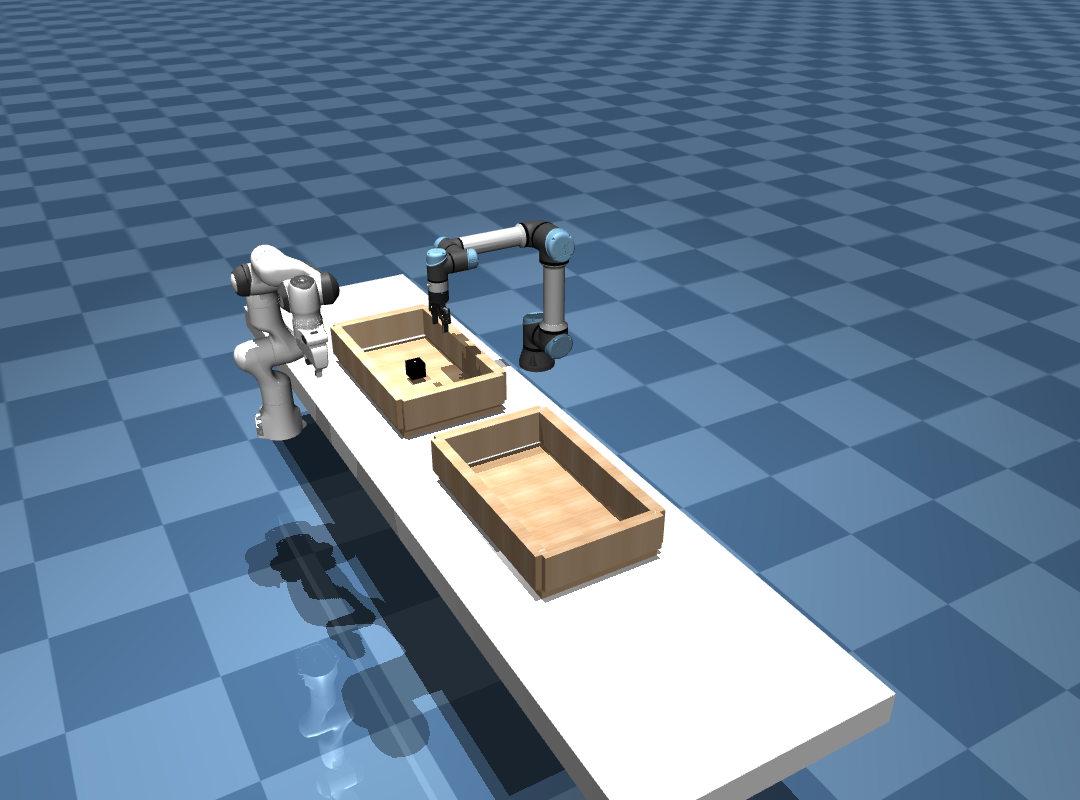

In [17]:
t.reset_to_home_pose()
t.render_image(cam_id=5)

## Imports

In [1]:
from dm_control import mjcf,mujoco
import PIL.Image

import copy
import os
import itertools
from IPython.display import clear_output
import numpy as np

%matplotlib inline

# Graphics-related
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython import display
import PIL.Image

from tempfile import NamedTemporaryFile
# Internal loading of video libraries.

# Use svg backend for figure rendering
%config InlineBackend.figure_format = 'svg'

# Font sizes
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


VIDEO_TAG = """<video controls>
 <source src="data:video/x-m4v;base64,{0}" type="video/mp4">
 Your browser does not support the video tag.
</video>"""

def anim_to_html(anim):
    if not hasattr(anim, '_encoded_video'):
        with NamedTemporaryFile(suffix='.mp4') as f:
            anim.save(f.name, fps=20, extra_args=['-vcodec', 'libx264'])
            video = open(f.name, "rb").read()
        anim._encoded_video = video.encode("base64")
    
    return VIDEO_TAG.format(anim._encoded_video)

# Inline video helper function
if os.environ.get('COLAB_NOTEBOOK_TEST', False):
  # We skip video generation during tests, as it is quite expensive.
  display_video = lambda *args, **kwargs: None
else:
  def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    video=anim.to_html5_video()

    html = display.HTML(video) 
  
    # draw the animation 
    display.display(html)

# Seed numpy's global RNG so that cell outputs are deterministic. We also try to
# use RandomState instances that are local to a single cell wherever possible.
np.random.seed(42)

## MJCF Task Building 

In [2]:
from rocobench.envs.task_mjcf_object_handover import TaskObjectHandover
from rocobench.envs.constants import *
from rocobench.envs.env_utils import prepend_robot_name

root_dir = os.getcwd()
task_robots = { 
            "panda": {
                "robot_config": prepend_robot_name("panda", PANDA_CONSTANTS.copy()),
                "robot_type": "panda",
                "file": root_dir + '/rocobench/envs/assets/panda/panda.xml',
                "worldbody_site_pos": [-0.5, -0.05, 0.1]
            
            },
            # "ur5e1":{
            #     "robot_config": prepend_robot_name("ur5e1", UR5E_ROBOTIQ_CONSTANTS.copy()),
            #     "robot_type": "ur5e1",
            #     "file": root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml',
            #     "worldbody_site_pos": [-0.5, -0.05, 0.1]
            # }, 

            "ur5e2":{
                "robot_config": prepend_robot_name("ur5e2", UR5E_ROBOTIQ_CONSTANTS.copy()),
                "robot_type": "ur5e2",
                "file": root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml',
                "worldbody_site_pos": [-0.5, 1.05, 0.1]
            }
        }

task = TaskObjectHandover(model_name="object_handover_task", 
                          project_root_dir="rocobench/envs/",
                          robots=task_robots, 
                          reset_to_home_pose=True, home_pose_key='pu')


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                    black_box [-0.5       0.5       0.22    ]
 4                      box_top [-0.5       0.5       0.25    ]
 5                   box_bottom [-0.5       0.5       0.19    ]
 6                       panda/ [-0.5      -0.05      0.1     ]
 7                  panda/link0 [-0.5      -0.05      0.1     ]
 8                  panda/link1 [-0.5      -0.05      0.433   ]
 9                  panda/link2 [-0.5      -0.05      0.433   ]
10                  panda/link3 [-0.5      -0.05      0.749   ]
11                  panda/link4 [-0.417    -0.05      0.749   ]
12                  panda/link5 [-0.0335   -0.05      0.832   ]
13                  panda/link6 [-0.0335   -0.05      0.832   ]
14                 

In [4]:
# task.model.equality.add("weld", name="ur5_box", body1="black_box", body2="ur5e1/robotiq_tip", relpose=[0,0, 0, 1, 0, 0, 0], active=False)
# task.model.equality.add("weld", name="keycard_panda", body1="keycard", body2="panda/panda_palm", relpose=[0,0, 0, 1, 0, 0, 0], active=False)
# task.set_physics()

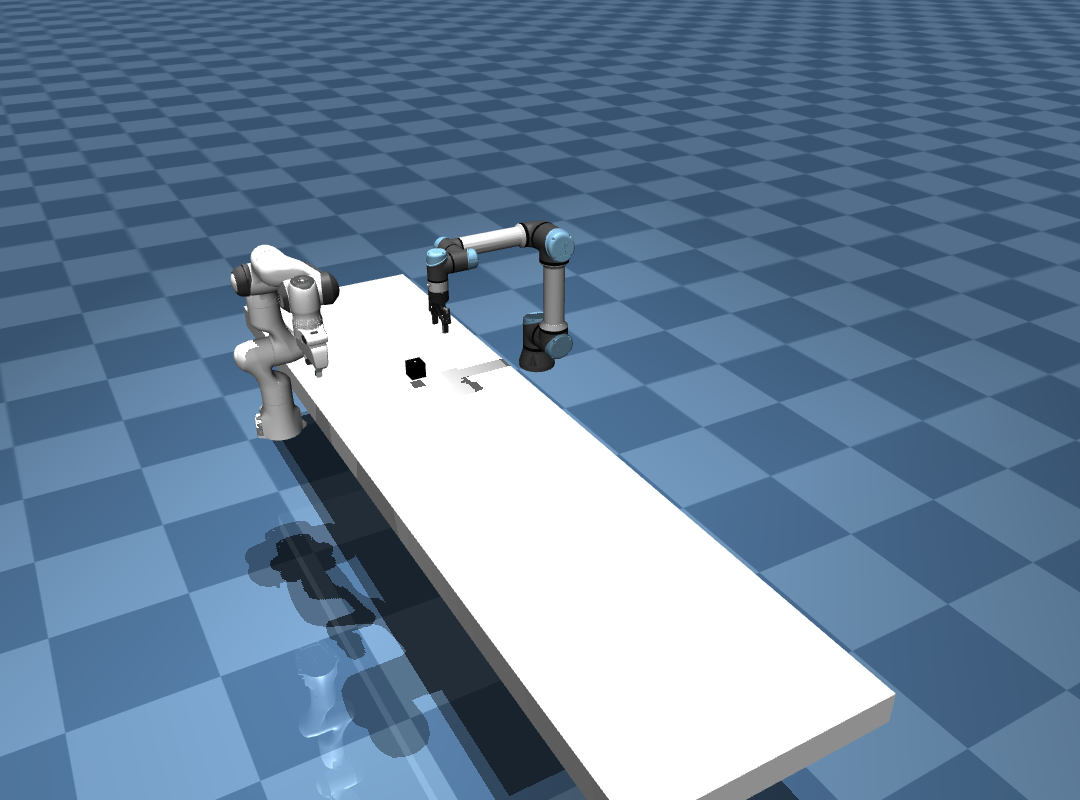

In [5]:
## Render ##
task.render_image(cam_id = 5)

In [6]:
task.robot_configs.keys()

dict_keys(['panda', 'ur5e', 'kinova'])

## Create SimRobots

In [7]:
import importlib
import rocobench.envs.robot as Robot

importlib.reload(Robot)

<module 'rocobench.envs.robot' from '/home/vignesh/robot-collab_vig/rocobench/envs/robot.py'>

In [8]:
s = np.array([])

In [9]:
ur5e_sim = Robot.SimRobot(task.physics,
              "ur5e1",  #   task_robots["ur5e"]["robot_type"], #name,
              task.robot_configs["ur5e"],
              '/home/vignesh/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
              '/home/vignesh/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
              task.model)

# panda_sim = SimRobot(task.physics,
#                      task_robots["panda"]["robot_type"], 
#                      task.robot_configs["panda"],
#                      '/home/adityadutt/curobo/src/curobo/content/assets/robot/franka_description/panda.urdf',
#                      '/home/adityadutt/curobo/src/curobo/content/configs/robot/panda.yml',
#                      task.model)

In [10]:
ur5e_sim.initalize_ik(task.physics)
ur5e_sim.initialize_motion_planner(task.physics)

In [11]:
ur5e_sim.collision_world.get_as_class().save_world_as_mesh("ur5e_mesh.obj")

In [15]:
result = ur5e_sim.solve_ik(task.physics, np.array([-0.5, 0.5, 0.5]))

print(result)

[-0.42577085 -2.0366616  -2.0419881  -1.205836   -1.4645422   1.5708085
 -0.46593305]


## Generate Trajectories

In [13]:
## Plan a trajectory to pick up the box

## Pre-grasp pose
task.physics.reset()
pre_grasp_pose = task.physics.named.data.qpos["box_free"]

_, pre_grasp_traj = ur5e_sim.plan(
    task.physics, 
    pre_grasp_pose[:3] + np.array([0, 0, 0.5]),
    start_state=task.physics.data.qpos[ur5e_sim.joint_idxs_in_qpos],
    time_dilation=0.5
)

## Handover Position
handover_pose = np.array([pre_grasp_pose[0], pre_grasp_pose[1], pre_grasp_pose[2] + 0.2, 
                           0, 0.7071068, 0, 0.7071068 ]) # 90 deg facing horizontally

_, handover_traj = ur5e_sim.plan(
    task.physics, 
    handover_pose[:3], 
    start_state=pre_grasp_traj[-1].copy(),
    time_dilation=0.5
)


In [33]:
pre_grasp_pose, handover_pose

(array([-0.5,  0.5,  0.1,  1. ,  0. ,  0. ,  0. ]),
 array([-0.5      ,  0.5      ,  0.3      ,  0.       ,  0.7071068,
         0.       ,  0.7071068]))

In [34]:
pre_grasp_traj.shape, handover_traj.shape

((92, 7), (62, 7))

In [16]:
trajectory = np.concatenate([pre_grasp_traj, handover_traj], axis=0)
grasp_idx = len(pre_grasp_traj) - 1
trajectory.shape

(158, 7)

In [36]:
task.physics.named.model.eq_active

FieldIndexer(eq_active):
0 ur5e1//unnamed_equality_0 [1]
1 ur5e1//unnamed_equality_1 [1]
2 ur5e1//unnamed_equality_2 [1]
3 ur5e2//unnamed_equality_0 [1]
4 ur5e2//unnamed_equality_1 [1]
5 ur5e2//unnamed_equality_2 [1]

## Visualize Trajectory

In [17]:
frames = []
ctrls=[]
duration = 10
framerate = 20
control_rate = 0.05
task.physics.reset()  # Reset state and time

while task.physics.data.time < duration:
  #target_pose=physics.named.data.xpos[target_body_top]
  #result=panda1.solve_ik(physics,target_pos=target_pose)
  #ctrl=panda1.map_qpos_to_joint_ctrl(result.qpos)
  t0 = task.physics.data.time

  idx = int(t0 / control_rate)
  if idx > len(trajectory) - 1:
    idx = len(trajectory) - 1
  
  # if idx == grasp_idx:
  #   task.physics.named.model.eq_active["ur5_box"] = 1

  task.physics.data.ctrl[ur5e_sim.joint_idxs_in_ctrl] = trajectory[idx]
  # physics.data.ctrl=ctrl
  #print(ctrl)
  while task.physics.data.time - t0< control_rate:
  #print(physics.data.ctrl)
    task.physics.step()
    if len(frames) < task.physics.data.time * framerate:
      pixels = task.physics.render(camera_id=5, width=800,height=800)
      frames.append(pixels)
display_video(frames, framerate)

## Multi-Arm Planner

In [10]:
# ur5e1 = Robot.SimRobot(task.physics,
#               "ur5e1", #name,
#               task.robot_configs["ur5e"].copy(),
#               '/home/vignesh/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
#               '/home/vignesh/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
#               task.model)

ur5e2 = Robot.SimRobot(task.physics,
              "ur5e2", #name,
              task.robot_configs["ur5e"].copy(),
              '/home/vignesh/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
              '/home/vignesh/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
              task.model)
panda = Robot.SimRobot(task.physics,
              "panda", #name,
              task.robot_configs["panda"].copy(),
              '/home/vignesh/curobo/src/curobo/content/assets/robot/franka_description/franka_panda.urdf',
              '/home/vignesh/curobo/src/curobo/content/configs/robot/franka.yml',
              task.model)

In [11]:
import rocobench.curobo_multi_arm as CuroboMultiArm
import rocobench.envs.world_config as W
importlib.reload(W)
importlib.reload(CuroboMultiArm)


<module 'rocobench.curobo_multi_arm' from '/home/vignesh/robot-collab_vig/rocobench/curobo_multi_arm.py'>

In [12]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                    black_box [-0.5       0.5       0.22    ]
 4                      box_top [-0.5       0.5       0.25    ]
 5                   box_bottom [-0.5       0.5       0.19    ]
 6                       panda/ [-0.5      -0.05      0.1     ]
 7                  panda/link0 [-0.5      -0.05      0.1     ]
 8                  panda/link1 [-0.5      -0.05      0.433   ]
 9                  panda/link2 [-0.5      -0.05      0.433   ]
10                  panda/link3 [-0.5      -0.05      0.749   ]
11                  panda/link4 [-0.417    -0.05      0.749   ]
12                  panda/link5 [-0.0335   -0.05      0.832   ]
13                  panda/link6 [-0.0335   -0.05      0.832   ]
14                 

In [13]:
multiarm_planner = CuroboMultiArm.MultiArmCurobo(task.physics, task.model, {"panda": panda, "ur5e2": ur5e2})

/home/vignesh/miniconda3/envs/roco/lib/python3.8/site-packages/urdfpy/urdf.py:2169: RuntimeWarning: invalid value encountered in true_divide
  value = value / np.linalg.norm(value)


[[-0.5, -0.05, 0.1, 1.0, 0.0, 0.0, 0.0], [-0.5, 1.05, 0.1, 1.0, 0.0, 0.0, 0.0]]
robot_cfg:
    kinematics:
        asset_root_path: /robot
        base_link: base_fixture_link
        collision_link_names:
        - panda_link0_1
        - panda_link1_1
        - panda_link2_1
        - panda_link3_1
        - panda_link4_1
        - panda_link5_1
        - panda_link6_1
        - panda_link7_1
        - panda_hand_1
        - panda_leftfinger_1
        - panda_rightfinger_1
        - attached_object_1
        - shoulder_link_2
        - upper_arm_link_2
        - forearm_link_2
        - wrist_1_link_2
        - wrist_2_link_2
        - wrist_3_link_2
        - tool_2
        collision_sphere_buffer: 0.004
        collision_spheres:
            forearm_link_2:
            -   center:
                - -0.01
                - 0.002
                - 0.031
                radius: 0.072
            -   center:
                - -0.387
                - 0.0
                - 0.014
       

In [14]:
multiarm_planner.initialize_motion_planner(task.physics)

In [45]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                    black_box [-0.5       0.5       0.22    ]
 4                      box_top [-0.5       0.5       0.25    ]
 5                   box_bottom [-0.5       0.5       0.19    ]
 6                       panda/ [-0.5      -0.05      0.1     ]
 7                  panda/link0 [-0.5      -0.05      0.1     ]
 8                  panda/link1 [-0.5      -0.05      0.433   ]
 9                  panda/link2 [-0.5      -0.05      0.433   ]
10                  panda/link3 [-0.5      -0.05      0.749   ]
11                  panda/link4 [-0.417    -0.05      0.749   ]
12                  panda/link5 [-0.0335   -0.05      0.832   ]
13                  panda/link6 [-0.0335   -0.05      0.832   ]
14                 

In [60]:
# multiarm_planner.collision_world.save_world_mesh("multiarm_mesh.obj")

In [15]:
task.physics.reset(0)
multiarm_traj = multiarm_planner.plan(task.physics, {"panda": [-0.2, 0.5, 0.6, 0, 1, 0, 0], "ur5e2": [-0.5, 0.5, 0.2, 0, 0.707, 0, 0.707]}, time_dilation = 0.25)

(14,)


In [16]:
multiarm_traj.shape, panda.joint_idxs_in_ctrl, ur5e2.joint_idxs_in_ctrl

((349, 14), [1, 2, 3, 4, 5, 6, 7], [9, 10, 11, 12, 13, 14, 15])

In [63]:
print(multiarm_traj[0:51, :])

[[ 0.00000000e+00 -1.57079995e+00 -1.57079995e+00  1.57079995e+00
  -1.57079995e+00 -1.57079995e+00  0.00000000e+00  0.00000000e+00
  -1.57079995e+00 -1.57079995e+00  1.57079995e+00 -1.57079995e+00
  -1.57079995e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.57079983e+00 -1.57079983e+00  1.57079983e+00
  -1.57079983e+00 -1.57079983e+00  0.00000000e+00  0.00000000e+00
  -1.57079983e+00 -1.57079983e+00  1.57079983e+00 -1.57079983e+00
  -1.57079983e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.57079995e+00 -1.57079995e+00  1.57079995e+00
  -1.57079995e+00 -1.57079995e+00  0.00000000e+00  0.00000000e+00
  -1.57079995e+00 -1.57079995e+00  1.57079995e+00 -1.57079995e+00
  -1.57079995e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.57079983e+00 -1.57079983e+00  1.57079983e+00
  -1.57079983e+00 -1.57079983e+00  0.00000000e+00  0.00000000e+00
  -1.57079983e+00 -1.57079983e+00  1.57079983e+00 -1.57079983e+00
  -1.57079983e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.57079995e+00 -1.57079995e+00  1.57079995e+00
  

In [19]:
frames = []
ctrls=[]
duration = 20
framerate = 20
control_rate = 0.02
task.physics.reset(0)  # Reset state and time

while task.physics.data.time < duration:

  t0 = task.physics.data.time

  idx = int(t0 / control_rate)
  if idx > len(multiarm_traj) - 1:
    idx = len(multiarm_traj) - 1
  
#   if idx == grasp_idx:
#     task.physics.named.model.eq_active["ur5_box"] = 1

  task.physics.data.ctrl[panda.joint_idxs_in_ctrl + ur5e2.joint_idxs_in_ctrl] = multiarm_traj[idx]

  while task.physics.data.time - t0< control_rate:
    task.physics.step()
    if len(frames) < task.physics.data.time * framerate:
      pixels = task.physics.render(camera_id=5, width=800,height=800)
      frames.append(pixels)
display_video(frames, framerate)

In [90]:
display_video(frames, framerate/5)